# Inferencia Swin Transformer: vector de probabilidades por imagen

Este notebook carga un checkpoint de Swin y predice una imagen individual.
Acepta formatos: jpg, jpeg, png, bmp, webp, tif, tiff.

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import timm
from torchvision import transforms

print('Torch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

c:\Users\jose.rodriguezb\Desktop\github_proyectos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.6.0+cu124
CUDA disponible: True
GPU: NVIDIA RTX A2000 Laptop GPU


In [2]:
# Configuracion
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = 9
class_labels = ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']

MODEL_NAME = 'swin_small_patch4_window7_224.ms_in22k_ft_in1k'
CKPT_PATH = Path('swin_small_patch4_window7_224.ms_in22k_ft_in1k.pth')

if not CKPT_PATH.exists():
    raise FileNotFoundError(f'No se encontro el checkpoint: {CKPT_PATH.resolve()}')

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

print('Dispositivo:', device)
print('Modelo:', MODEL_NAME)
print('Checkpoint:', CKPT_PATH.resolve())

Dispositivo: cuda
Modelo: swin_small_patch4_window7_224.ms_in22k_ft_in1k
Checkpoint: C:\Users\jose.rodriguezb\Desktop\github_proyectos\Clasificador_Edad\cnn\swin_small_patch4_window7_224.ms_in22k_ft_in1k.pth


In [3]:
def crear_modelo_swin(model_name, num_classes, device):
    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    return model.to(device)


def extraer_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ['state_dict', 'model_state_dict', 'model', 'net']:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                checkpoint = checkpoint[key]
                break

    if not isinstance(checkpoint, dict):
        raise ValueError('El checkpoint no contiene un state_dict valido.')

    cleaned = {}
    for k, v in checkpoint.items():
        new_k = k.replace('module.', '') if isinstance(k, str) else k
        cleaned[new_k] = v
    return cleaned


def cargar_modelo(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = extraer_state_dict(checkpoint)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    if missing:
        print(f'Aviso: {len(missing)} claves faltantes al cargar pesos.')
    if unexpected:
        print(f'Aviso: {len(unexpected)} claves inesperadas en checkpoint.')

    model.eval()
    return model


def normalizar_imagen_swin():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


def validar_imagen(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'No existe la imagen: {path}')

    ext = path.suffix.lower()
    if ext not in VALID_EXTENSIONS:
        raise ValueError(f'Formato no soportado: {ext}. Usa uno de: {sorted(VALID_EXTENSIONS)}')

    return path


@torch.no_grad()
def predecir_imagen(model, image_path, class_labels, device):
    image_path = validar_imagen(image_path)

    transform = normalizar_imagen_swin()
    image = Image.open(image_path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(device)

    logits = model(tensor)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = class_labels[pred_idx]

    return {
        'image_path': str(image_path),
        'pred_idx': pred_idx,
        'pred_label': pred_label,
        'prob_vector': probs,
    }

In [4]:
model = crear_modelo_swin(MODEL_NAME, num_classes=num_classes, device=device)
model = cargar_modelo(model, CKPT_PATH, device)
print('Modelo Swin cargado correctamente.')

Modelo Swin cargado correctamente.


## Inferencia de una imagen

En IMAGE_PATH coloca la ruta a tu imagen (jpg, jpeg, png, bmp, webp, tif, tiff).

Imagen: bob_esponja.jpg
Clase predicha: 3-9

Vector de probabilidades (en el orden de class_labels):
[0.15213038 0.593349   0.0149412  0.05795226 0.07989445 0.07572141
 0.00999703 0.0084985  0.00751576]


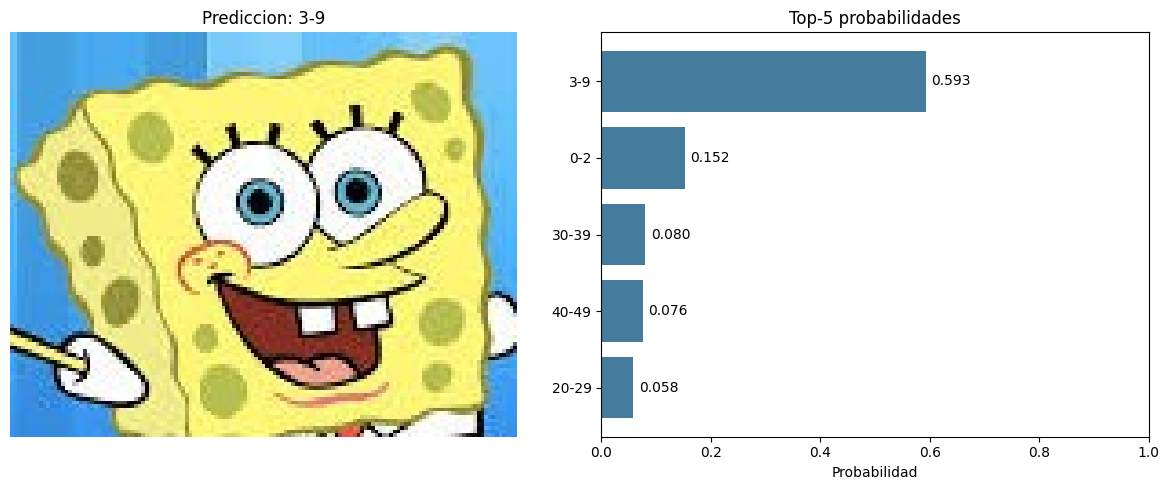


Top-5 clases:
1. 3-9: 0.5933
2. 0-2: 0.1521
3. 30-39: 0.0799
4. 40-49: 0.0757
5. 20-29: 0.0580


In [17]:
# Ejemplo: IMAGE_PATH = 'C:/ruta/a/tu_imagen.jpg'
IMAGE_PATH = 'bob_esponja.jpg'

resultado = predecir_imagen(model, IMAGE_PATH, class_labels, device)

print('Imagen:', resultado['image_path'])
print('Clase predicha:', resultado['pred_label'])

print('\nVector de probabilidades (en el orden de class_labels):')
print(resultado['prob_vector'])

top5_idx = np.argsort(resultado['prob_vector'])[::-1][:5]
top5_labels = [class_labels[i] for i in top5_idx]
top5_probs = resultado['prob_vector'][top5_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

img = Image.open(resultado['image_path']).convert('RGB')
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Prediccion: {resultado['pred_label']}")

y_pos = np.arange(len(top5_labels))
axes[1].barh(y_pos, top5_probs, color='#457b9d')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top5_labels)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probabilidad')
axes[1].set_title('Top-5 probabilidades')

for i, p in enumerate(top5_probs):
    axes[1].text(float(p) + 0.01, i, f"{float(p):.3f}", va='center')

plt.tight_layout()
plt.show()

print('\nTop-5 clases:')
for rank, idx in enumerate(top5_idx, start=1):
    print(f"{rank}. {class_labels[idx]}: {resultado['prob_vector'][idx]:.4f}")